# Introduction to MIMIC-IV

## EHR of patients from Intensive Care Unit and Emergency Department

[MIMIC](https://mimic.mit.edu) (Medical Information Mart for Intensive Care) is a **large, publicly available database** sourced from the EHR of the Beth Israel Deaconess Medical Center. 

The [MIMIC-IV](https://mimic.mit.edu/docs/iv/) version includes information on patient measurements, orders, diagnoses, procedures, treatments, and deidentified free-text clinical notes. MIMIC-IV is intended to support a wide array of research studies and educational material, helping to reduce barriers to conducting clinical research.

MIMIC-IV is separated into “modules” to reflect the provenance of the data. There are currently five modules:

- hosp - all data acquired from the hospital wide electronic health record. Information covered includes patient and admission information, laboratory measurements, microbiology, medication administration, and billed diagnoses.
- icu - information collected from the clinical information system used within the ICU. Documented data includes intravenous administrations, ventilator settings, and other charted items.
- ed - data for emergency department patients collected while they are in the ED. Information includes reason for admission, triage assessment, vital signs, and medicine reconciliaton.
- cxr - lookup tables linking patient identifiers with MIMIC-CXR study_id and dicom_id, allowing analysis of patient chest x-rays to be linked with the clinical data from other MIMIC-IV modules.
- note - deidentified free-text clinical notes (STILL NOT PUBLICLY AVAILABLE).



## MIMIC-IV hosp and icu modules:

[MIMIC-IV data](https://physionet.org/content/mimiciv/3.1/) contains data for over 65,000 patients admitted to an ICU and over 200,000 patients admitted to the emergency department  between **2008 - 2022**. 

MIMIC-IV is a relational database containing **31 tables of data** relating to patients who stayed within the ICU and ED, which are organized in two modules. Module hosp (tables as *patients*, *admissions* and *transfers*) and module icu (tables as *chartevents* and *outputevents*).

Table *chartevents* contains all the charted data available for a patient and table *d_items* is a dictionary table with definitions for all items in the ICU databases. You can find more info [here](https://mimic.mit.edu/docs/iv/modules/icu/chartevents/).

The tables are linked by identifiers which usually have the suffix *id*. See section below.

Tables pre-fixed with “*d_*” are dictionaries and provide definitions for identifiers. For example, every row of *chartevents* is associated with a single itemid which represents the concept measured, but it does not contain the actual name of the drug. By joining *chartevents* and *d_items* on itemid, it is possible to identify what concept a given itemid represents.



### What is a patient record?

Since a patient may have been admitted several times during the period in which our data were collected, it is important to understand exactly how to identify patients and his/her stay(s).
There are essentially identifiers for data associated with any given patient:

- Subject ID (*subject_id*) - The patients table contains information for each unique subject_id. subject_id is sourced from the hospital, and is an anonymized version of a patient’s medical record number.

- Hospital admission ID (*hadm_id*) - The admissions table contains information for each unique hadm_id. hadm_id is sourced from the hospital, and is an anonymized version of an identifier assigned to each patient hospitalization. Each patient may have many hadm_ids associated with his/her unique Subject ID.

- Transfer ID (*transfer_id*) - The transfers table contains information for each unique transfer_id. transfer_id is an artificially generated identifier which is uniquely assigned to a ward stay for an individual patient.

- stay ID (*stay_id*) - The transfers table also contains the stay_id. This is an artificially generated identifier which groups reasonably contiguous (fewer than 24 hours apart) episodes of care. The stay_id present in icustays is derived from the stay_id values in the transfers table.

Information about the patient identifiers can be found [here](https://mimic.mit.edu/docs/iv/about/concepts/)


## Data Access


The database, although de-identified, still contains detailed information regarding the clinical care of patients, so must be treated with appropriate care and respect and researchers seeking to use the database must formally request access with the steps explained [here](https://mimic.mit.edu/docs/gettingstarted/).

To allow researchers to ascertain whether the database is suitable for their work, the MIMIC Physionet team have manually curated a demo subset, which contains information for 100 patients also present in the MIMIC-IV Clinical Database. The MIMIC-IV Clinical Database Demo can be download from [here](https://physionet.org/content/mimic-iv-demo/2.2/).

After downloading the demo dataset we can start working with the tables in the code below.




## Connect to the database

We have two alternatives to work with the MIMIC data:
1. We can use the sqlite3 library to connect to the MIMIC database. Once the connection is established, we'll run a simple SQL query.
   
2. Load data from csv and extract and fuse the necessary information. 

When working with the demo dataset the two alternatives are valid to deal with all the tables, since the files are small enought to read them diretly as pandas DataFrames. We will use option 2 in this notebook.

Alternative 1 will be the only option when working with some of the large tables in the original data set. 
Some of the files (INPUTEVENTS_CV, LABEVENTS, NOTEEVENTS, CHARTEVENTS) are intractable directly with pandas DataFrames due to memory limitations. The creation of databases associated to these files is necessary because the use of SQL to query desired instances and put it in the form of pandas DataFrame will help to automate the process of feature extraction.

# Exploring the trajectory of a single patient

### Example to complete:

Let us explore the MIMIC-IV dataset by ploting different vital signs measurements of a patient (time series extracted from different tables). The analysis of these monitoring data helps doctors to understand the state severity and evolution of the patient depending on the pathophysiology of the disease or injury.

In MIMIC, we define *trends* to be a time series of parameters derived from the waveforms by the bedside monitors, such as heart rate, systolic blood pressure, cardiac output and relative oxygen saturation. Of course, time series of repeated clinical measurements are also found in the relational database, such as pH levels, laboratory values and administered medications.



### Some details about the tables that we are using in this example

**Table ICUSTAYS**:

Table which defines each STAY_ID in the database, i.e. defines a single ICU stay.


**Table CHARTEVENTS**:

Table which contains all charted data for all patients.

One of the columns is ITEMID which is the identifier for a single measurement type in the database. Each row associated with one ITEMID (e.g. 212) corresponds to an instantiation of the same measurement (e.g. heart rate).

Identifiers which specify the patient: SUBJECT_ID is unique to a patient, HADM_ID is unique to a patient hospital stay and STAY_ID is unique to a patient ICU stay.


**Table D_ITEMS**:

Dictionary of ITEMIDs appearing in the MIMIC database, except those that relate to laboratory tests (which are stored in D_LABITEMS).

This table defines ITEMID, which represents measurements in the database. 
The ITEMID column is an alternate primary key to this table: it is unique to each row.


### Import Python libraries

We first need to import some tools for working with data in Python. 
- NumPy is for working with numbers
- Pandas is for analysing data
- MatPlotLib is for making plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.ion()

### Load data and combine the information

After download the MIMIC-IV Clinical Database Demo, we are going to use the CHARTEVENTS, ICUSTAYS, D_ITEMS, LABEVENTS and D_LABITEMS tables to combine and explore the information.


In [2]:
path = "data/mimic-iv-clinical-database-demo-2.2/" #path to the data folder 

### Load the CHARTEVENTS table


Let us read the CHARTEVENTS table and remove noninformative columns.

In [3]:
df_chartevents = pd.read_csv(path+'icu/chartevents.csv.gz')
print(df_chartevents.shape)
print('unique subject_id:', df_chartevents.subject_id.nunique())
print('unique hadm_id :', df_chartevents.hadm_id.nunique())
df_chartevents.head()

(668862, 11)
unique subject_id: 100
unique hadm_id : 128


,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,225054,On,NaN,NaN,0.0
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:43:00,223769,100,100.0,%,0.0
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,223956,Atrial demand,NaN,NaN,0.0
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:47:00,224866,Yes,NaN,NaN,0.0
4,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-15 23:45:00,227341,No,0.0,NaN,0.0


In [4]:
df_chartevents.drop(df_chartevents.columns.difference(['subject_id', 'hadm_id', 'stay_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom', 'error']), axis=1, inplace=True)
print(df_chartevents.shape)
df_chartevents.head()

(668862, 8)


,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom
0,10005817,20626031,32604416,2132-12-16 00:00:00,225054,On,NaN,NaN
1,10005817,20626031,32604416,2132-12-16 00:00:00,223769,100,100.0,%
2,10005817,20626031,32604416,2132-12-16 00:00:00,223956,Atrial demand,NaN,NaN
3,10005817,20626031,32604416,2132-12-16 00:00:00,224866,Yes,NaN,NaN
4,10005817,20626031,32604416,2132-12-16 00:00:00,227341,No,0.0,NaN


In [5]:
df_chartevents['stay_id'].unique()

array([32604416, 36084484, 34629895, 32145159, 34617352, 32506122,
       39804682, 39711498, 35258379, 37057036, 37323533, 31248398,
       39268883, 35024147, 37093652, 30913302, 30864406, 35065627,
       38507547, 34600477, 33177122, 36059427, 39864867, 31338022,
       35146796, 34592300, 38875437, 37049133, 38587181, 32496174,
       38430513, 35436337, 35544374, 39623478, 38329661, 35479615,
       33281088, 35629889, 30425410, 39880770, 36893762, 39061571,
       37648963, 37067082, 36558922, 35446858, 39544395, 39084876,
       31494479, 38229329, 37200209, 35679826, 38540883, 38017367,
       37293400, 30932571, 39492446, 35889503, 32155744, 35396193,
       30757476, 34578020, 35009126, 36107367, 36871784, 31316840,
       32166508, 38137964, 31205490, 39142259, 30458995, 32128372,
       30101877, 32314488, 37267577, 33558396, 33846653, 38559363,
       34324099, 34499716, 35026312, 35636875, 33083787, 36753294,
       31552399, 31959184, 32554129, 36091287, 32119961, 37127

### Select a patient

Let us load the chartevents data for a single patient. To select the information for a single patient, we use the STAY_ID which is the identifiers which is unique to a patient ICU stay.

We select the patient with stay_id = 34629895.

You can replace this 'selected_stay_id' if you want to explore other patient records.

In [6]:
# Filter the CHARTEVENTS dataframe for the selected stay_id:
selected_stay_id = 30757476 
df_chartevents = df_chartevents[df_chartevents['stay_id']==selected_stay_id]

In [7]:
df_chartevents.head()
print(df_chartevents.shape)

(13321, 8)


### Load the ICUSTAYS table

Le'ts read the table ICUSTAYS to get the information of the intime (the date and time the patient was transferred into the ICU).

In [8]:
df_icustays = pd.read_csv(path+'icu/icustays.csv.gz')
print(df_icustays.shape)
df_icustays.head()

(140, 8)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [9]:
df_icustays.drop(df_icustays.columns.difference(['subject_id', 'hadm_id', 'stay_id', 'intime']), axis=1, inplace=True)
print(df_icustays.shape)
df_icustays.head()

(140, 4)


,subject_id,hadm_id,stay_id,intime
0,10018328,23786647,31269608,2154-04-24 23:03:44
1,10020187,24104168,37509585,2169-01-15 04:56:00
2,10020187,26842957,32554129,2170-02-24 18:18:46
3,10012853,27882036,31338022,2176-11-26 02:34:49
4,10020740,25826145,32145159,2150-06-03 20:12:32


In [10]:
# Let's create a new dataframe including the temporal information to our chartevents dataframe 
df_ce = pd.merge(df_chartevents,df_icustays,how='left',on=['subject_id', 'hadm_id','stay_id'])
print(df_ce.shape)
df_ce

(13321, 9)


,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom,intime
0,10020944,29974575,30757476,2131-03-08 00:00:00,228411,Some resistance,4.0,NaN,2131-02-27 16:40:00
1,10020944,29974575,30757476,2131-03-08 00:00:00,228409,Some resistance,4.0,NaN,2131-02-27 16:40:00
2,10020944,29974575,30757476,2131-03-08 00:00:00,224769,Warm,NaN,NaN,2131-02-27 16:40:00
3,10020944,29974575,30757476,2131-03-08 00:00:00,224188,WNL,NaN,NaN,2131-02-27 16:40:00
4,10020944,29974575,30757476,2131-03-08 00:00:00,228337,No,0.0,NaN,2131-02-27 16:40:00
...,...,...,...,...,...,...,...,...,...
13316,10020944,29974575,30757476,2131-02-28 13:24:20,220001,.Care Plan - Impaired Tissue Perfusion,NaN,NaN,2131-02-27 16:40:00
13317,10020944,29974575,30757476,2131-02-28 03:21:37,220001,.Care Plan - Impaired Tissue Perfusion,NaN,NaN,2131-02-27 16:40:00
13318,10020944,29974575,30757476,2131-03-08 02:31:26,220001,.Care Plan - Altered Respiratory Function: Imp...,NaN,NaN,2131-02-27 16:40:00
13319,10020944,29974575,30757476,2131-02-28 13:23:28,220001,.Care Plan - Impaired Tissue Perfusion,NaN,NaN,2131-02-27 16:40:00


### Load the D_IMTEMS table

Le'ts read the table D_ITEMS to get information of the label of the item.

From table D_ITEMS we can link each ITEMID to a measure of a concrete variable or feature.

In [11]:
df_ditems = pd.read_csv(path+'icu/d_items.csv.gz')
print(df_ditems.shape)
df_ditems.head()

(4014, 9)


,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,226228,Gender,Gender,chartevents,ADT,NaN,Text,NaN,NaN
1,226545,Race,Race,chartevents,ADT,NaN,Text,NaN,NaN
2,229877,Suction events (CH),Suction events (CH),chartevents,ECMO,NaN,Text,NaN,NaN
3,229875,Oxygenator visible (CH),Oxygenator visible (CH),chartevents,ECMO,NaN,Text,NaN,NaN
4,229266,Cannula sites visually inspected (ECMO),Cannula sites visually inspected (ECMO),chartevents,ECMO,NaN,Text,NaN,NaN


In [12]:
df_ditems.drop(df_ditems.columns.difference(['itemid', 'label', 'unitname']), axis=1, inplace=True)
print(df_ditems.shape)
df_ditems.head()

(4014, 3)


,itemid,label,unitname
0,226228,Gender,NaN
1,226545,Race,NaN
2,229877,Suction events (CH),NaN
3,229875,Oxygenator visible (CH),NaN
4,229266,Cannula sites visually inspected (ECMO),NaN


In [13]:
df_ce.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid', 'value',
       'valuenum', 'valueuom', 'intime'],
      dtype='object')

In [14]:
df_ce=pd.merge(df_ce, df_ditems,how='left',on=['itemid'])
print(df_ce.shape)
df_ce.head()

(13321, 11)


,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom,intime,label,unitname
0,10020944,29974575,30757476,2131-03-08 00:00:00,228411,Some resistance,4.0,NaN,2131-02-27 16:40:00,Strength R Leg,NaN
1,10020944,29974575,30757476,2131-03-08 00:00:00,228409,Some resistance,4.0,NaN,2131-02-27 16:40:00,Strength L Arm,NaN
2,10020944,29974575,30757476,2131-03-08 00:00:00,224769,Warm,NaN,NaN,2131-02-27 16:40:00,LUE Temp,NaN
3,10020944,29974575,30757476,2131-03-08 00:00:00,224188,WNL,NaN,NaN,2131-02-27 16:40:00,PICC Line Site Appear,NaN
4,10020944,29974575,30757476,2131-03-08 00:00:00,228337,No,0.0,NaN,2131-02-27 16:40:00,CAM-ICU MS Change,NaN


### Normalization of time

Use charttime (which records the time at which an observation was made, and is usually the closest proxy to the time the data was actually measured) and intime (which provides the date and time the patient was transferred into the ICU) to compute the hours of the observation since the admission to the ICU.

In [15]:
a = (pd.to_datetime(df_ce['charttime']) - pd.to_datetime(df_ce['intime']))
hours = a.dt.total_seconds()/3600
df_ce['hours'] = hours
df_ce

,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom,intime,label,unitname,hours
0,10020944,29974575,30757476,2131-03-08 00:00:00,228411,Some resistance,4.0,NaN,2131-02-27 16:40:00,Strength R Leg,NaN,199.333333
1,10020944,29974575,30757476,2131-03-08 00:00:00,228409,Some resistance,4.0,NaN,2131-02-27 16:40:00,Strength L Arm,NaN,199.333333
2,10020944,29974575,30757476,2131-03-08 00:00:00,224769,Warm,NaN,NaN,2131-02-27 16:40:00,LUE Temp,NaN,199.333333
3,10020944,29974575,30757476,2131-03-08 00:00:00,224188,WNL,NaN,NaN,2131-02-27 16:40:00,PICC Line Site Appear,NaN,199.333333
4,10020944,29974575,30757476,2131-03-08 00:00:00,228337,No,0.0,NaN,2131-02-27 16:40:00,CAM-ICU MS Change,NaN,199.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
13316,10020944,29974575,30757476,2131-02-28 13:24:20,220001,.Care Plan - Impaired Tissue Perfusion,NaN,NaN,2131-02-27 16:40:00,Problem List,NaN,20.738889
13317,10020944,29974575,30757476,2131-02-28 03:21:37,220001,.Care Plan - Impaired Tissue Perfusion,NaN,NaN,2131-02-27 16:40:00,Problem List,NaN,10.693611
13318,10020944,29974575,30757476,2131-03-08 02:31:26,220001,.Care Plan - Altered Respiratory Function: Imp...,NaN,NaN,2131-02-27 16:40:00,Problem List,NaN,201.857222
13319,10020944,29974575,30757476,2131-02-28 13:23:28,220001,.Care Plan - Impaired Tissue Perfusion,NaN,NaN,2131-02-27 16:40:00,Problem List,NaN,20.724444


We keep the columns: STAY_ID,	HOURS,	LABEL,	VALUE,	VALUENUM,	VALUEUOM.

In [16]:
df_ce1 = df_ce.copy()
df_ce1.drop(df_ce1.columns.difference(['stay_id','hours', 'label', 'value', 'valuenum', 'valueuom']), axis=1, inplace=True)
print(df_ce1.shape)
df_ce1.head()

(13321, 6)


,stay_id,value,valuenum,valueuom,label,hours
0,30757476,Some resistance,4.0,NaN,Strength R Leg,199.333333
1,30757476,Some resistance,4.0,NaN,Strength L Arm,199.333333
2,30757476,Warm,NaN,NaN,LUE Temp,199.333333
3,30757476,WNL,NaN,NaN,PICC Line Site Appear,199.333333
4,30757476,No,0.0,NaN,CAM-ICU MS Change,199.333333


### Review the patient's heart rate

We can select individual columns using the column name. 
- For example, if we want to select just the label column (coming from D_ITEMS table), we write **```ce.label```** or alternatively **```ce['label']```**

In [17]:
# Select a single column
df_ce1['label']

0               Strength R Leg
1               Strength L Arm
2                     LUE Temp
3        PICC Line Site Appear
4            CAM-ICU MS Change
                 ...          
13316             Problem List
13317             Problem List
13318             Problem List
13319             Problem List
13320             Problem List
Name: label, Length: 13321, dtype: object

In a similar way, we can select rows from data using indexes. 
- For example, to select rows where the label is equal to 'Heart Rate', we would create an index using **```[ce.label=='Heart Rate']```** 

In [18]:
# Select just the heart rate rows using an index
# print all the unique labels
for label in sorted(df_ce1['label'].unique()):
    print(label)

18 G Infiltration Scale
18 G Phlebitis Scale
18 Gauge Dressing Occlusive
18 Gauge placed in outside facility
18 Gauge placed in the field
20 G Infiltration Scale
20 G Phlebitis Scale
20 Gauge Dressing Occlusive
20 Gauge placed in outside facility
20 Gauge placed in the field
ABP Alarm Source
ALT
ART Blood Pressure Alarm - High
ART Blood Pressure Alarm - Low
ART Blood Pressure Alarm Source
AST
Abdominal Assessment
Activity
Activity Tolerance
Admission Weight (Kg)
Admission Weight (lbs.)
Alarms On
Albumin
Alkaline Phosphate
All Medications Tolerated without Adverse Side Effects
Altered Mental Status  NCP - Expected outcomes
Altered Mental Status  NCP - Interventions
Altered Mental Status  NCP - Plan revised
Altered Mental Status  NCP - Problem resolved
Altered Respiratory Status NCP - Expected outcomes
Altered Respiratory Status NCP - Interventions
Altered Respiratory Status NCP - Plan revised
Altered Respiratory Status NCP - Problem resolved
Ambulatory aid
Ammonia
Anion gap
Anti Embolic

The valuenum (coming from CHARTEVENTS table) contains the numerical time series of this label which can be ploted and analyzed.

In [19]:
df_ce1[df_ce1.label=='Heart Rate'].shape

(218, 6)

### Plot 1: How did the patients heart rate change over time?

Using the methods described above to select our data of interest, we can create our x and y axis values to create a time series plot of heart rate.

The index corresponds to the number of the row in our dataframe.

In [20]:
print(df_ce1.index[df_ce1.label=='Heart Rate'])

Index([  49,  108,  113,  127,  232,  253,  267,  277,  291,  300,
       ...
       7113, 7124, 7161, 7212, 7313, 7320, 7325, 7943, 9517, 9897],
      dtype='int64', length=218)


Which timestamps have the corresponding heart rate measurement?

In [21]:
print(df_ce1.hours[df_ce1.label=='Heart Rate'])

49      199.333333
108     200.333333
113     201.333333
127     202.333333
232     203.333333
           ...    
7320    197.333333
7325    198.333333
7943      1.433333
9517     58.700000
9897     17.766667
Name: hours, Length: 218, dtype: float64


In [22]:
df_ce1=df_ce1.set_index('hours')
df_ce1=df_ce1.sort_index()

Text(0.5, 1.0, 'Heart rate over time from admission to the intensive care unit')

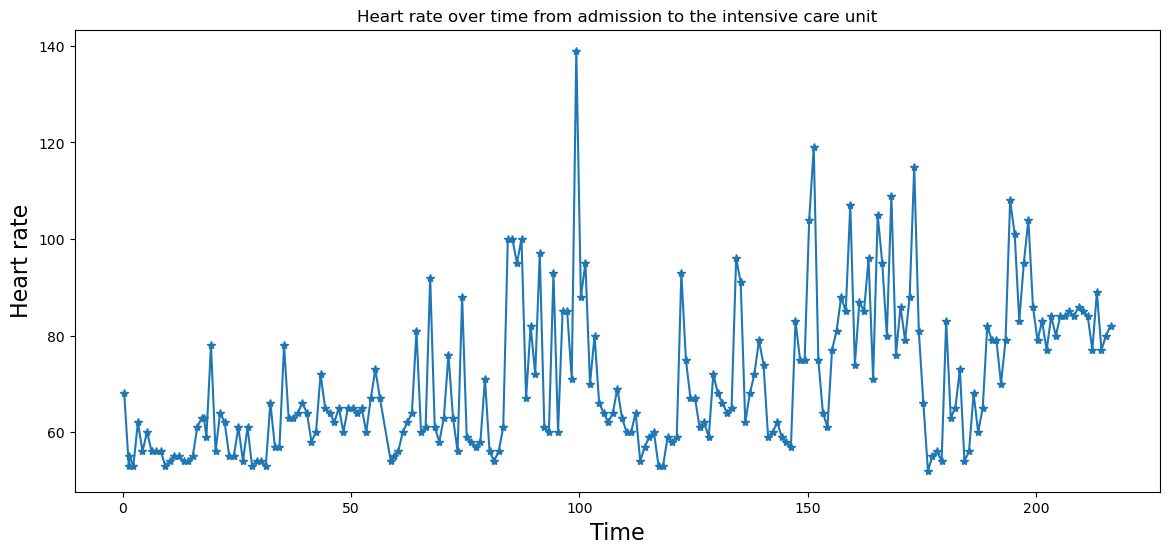

In [23]:
# Set x equal to the times
x_hr = df_ce1.index[df_ce1.label=='Heart Rate']

# Set y equal to the heart rates
y_hr = df_ce1.valuenum[df_ce1.label=='Heart Rate']

# Plot time against heart rate
plt.figure(figsize=(14, 6))
plt.plot(x_hr,y_hr,'*-')

plt.xlabel('Time',fontsize=16)
plt.ylabel('Heart rate',fontsize=16)
plt.title('Heart rate over time from admission to the intensive care unit')

**Observation**: TO COMPLETE.
Add what you observe in the plot.

Single patient tracked over 225 hours (aprox 9.5 days) in the ICU. Measurements every 1-2 hours aprox.
- hours 0-50 -> low and stable HR, possibly sedated or controlled
- hours 50-90 -> climb towars 80-90 bpm, more variability
- hours 100 -> spike to 140 bpm, arrhythmia?
- hours 100-150 -> hr drops back but high variability
- hours 150-225 -> persistent elevated hr, and erratic

### Plot 2: How did the patients respiratory rate change over time?

Now, let us plot the respiratory rate in the same way.

In [41]:
# TO COMPLETE
rr = df_ce1[df_ce1['label'] == 'Respiratory Rate'].copy()
rr

,stay_id,value,valuenum,valueuom,label
hours,,,,,
0.350000,30757476,12,12.0,insp/min,Respiratory Rate
1.333333,30757476,16,16.0,insp/min,Respiratory Rate
1.433333,30757476,16,16.0,insp/min,Respiratory Rate
2.333333,30757476,13,13.0,insp/min,Respiratory Rate
3.333333,30757476,20,20.0,insp/min,Respiratory Rate
...,...,...,...,...,...
212.333333,30757476,23,23.0,insp/min,Respiratory Rate
213.333333,30757476,15,15.0,insp/min,Respiratory Rate
214.333333,30757476,18,18.0,insp/min,Respiratory Rate


Text(0.5, 1.0, 'Respiratory rate over time from admission to the intensive care unit')

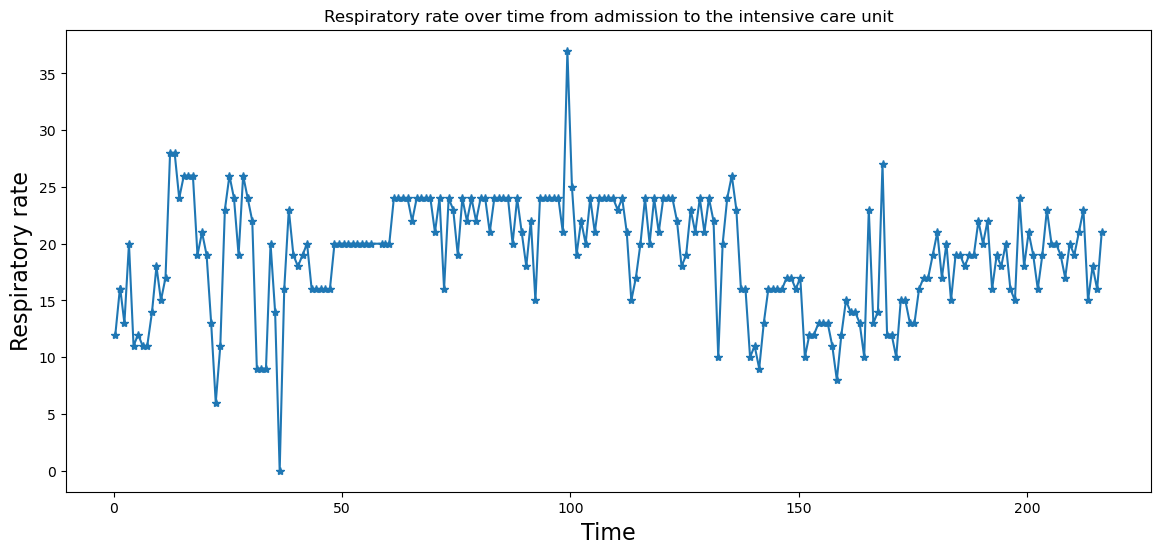

In [42]:
x_rr = rr.index[rr.label=='Respiratory Rate']
y_rr = rr.valuenum[rr.label=='Respiratory Rate']

plt.figure(figsize=(14, 6))
plt.plot(x_rr, y_rr, '*-')
plt.xlabel('Time', fontsize=16)
plt.ylabel('Respiratory rate', fontsize=16)
plt.title('Respiratory rate over time from admission to the intensive care unit')

**Observation**: TO COMPLETE.
Add what you observe in the plot.

We observe parallel patterns with the heart rate plot:
- hours 0-30 -> 6 to 28 br/min, high variability, peaks to 28
- hours 38 -> 0 br/min, apnea event?
- hours 50-95 -> plateau, too flat to be natural, possible intubated to a ventilator due to previous event
- hours 100 -> spike, matched HR
- hours 100-160 -> 9-25 br/min, wide swings
- hours 160-225 -> 15-24 br/min, more settled than before, but still elevated

At first in the HR plot I though the spike at 100h could be a data quality issue (outlier that needed to be cleaned). After seeing the RR over time, this can indicate a real clinical event.

### Plot 3: Did these patient's vital signs breach any alarm thresholds?

Alarm systems in the intensive care unit are commonly based on high and low thresholds defined by the carer.
False alarms are often a problem and so thresholds may be set arbitrarily to reduce alarms. As a result, alarm settings carry limited information.

(0.0, 55.0)

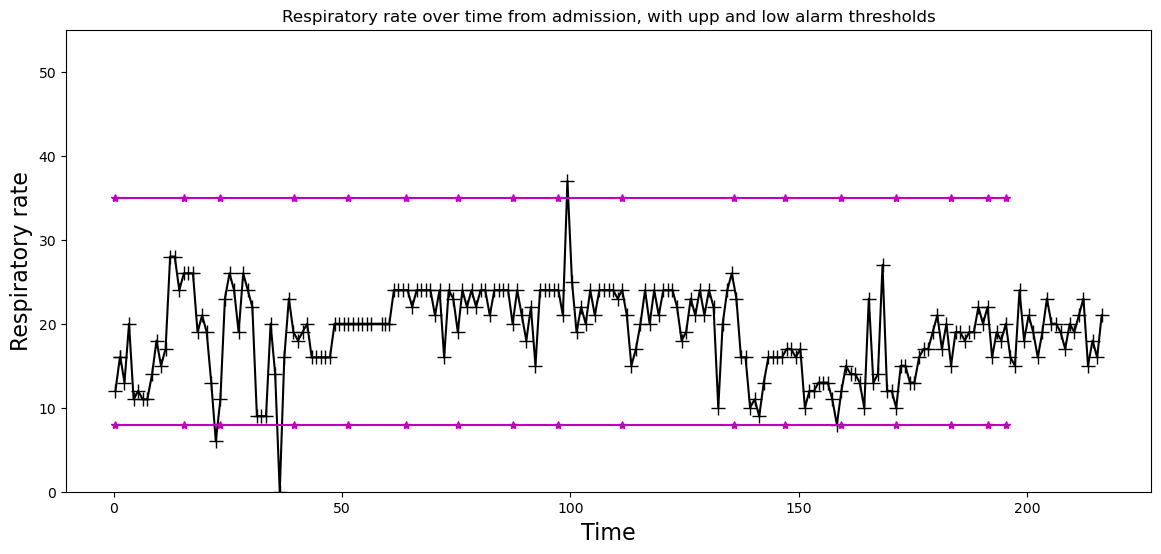

In [43]:
# Let's plot the Respiratory rate over time from admission, with upper and lower alarm thresholds

plt.figure(figsize=(14, 6))

plt.plot(df_ce1.index[df_ce1.label=='Respiratory Rate'], 
         df_ce1.valuenum[df_ce1.label=='Respiratory Rate'],
         'k-+', markersize=10)

plt.plot(df_ce1.index[df_ce1.label=='Resp Alarm - High'], 
         df_ce1.valuenum[df_ce1.label=='Resp Alarm - High'],
         'm-*')

plt.plot(df_ce1.index[df_ce1.label=='Resp Alarm - Low'], 
         df_ce1.valuenum[df_ce1.label=='Resp Alarm - Low'],
         'm-*')

plt.xlabel('Time',fontsize=16)
plt.ylabel('Respiratory rate',fontsize=16)
plt.title('Respiratory rate over time from admission, with upp and low alarm thresholds')
plt.ylim(0,55)


**Observation:** TO COMPLETE. 
Based on the plotted data, would the alarms have been triggered for this patient?

Yes, in hours 38 (0 br/min), hours 350 and 450.

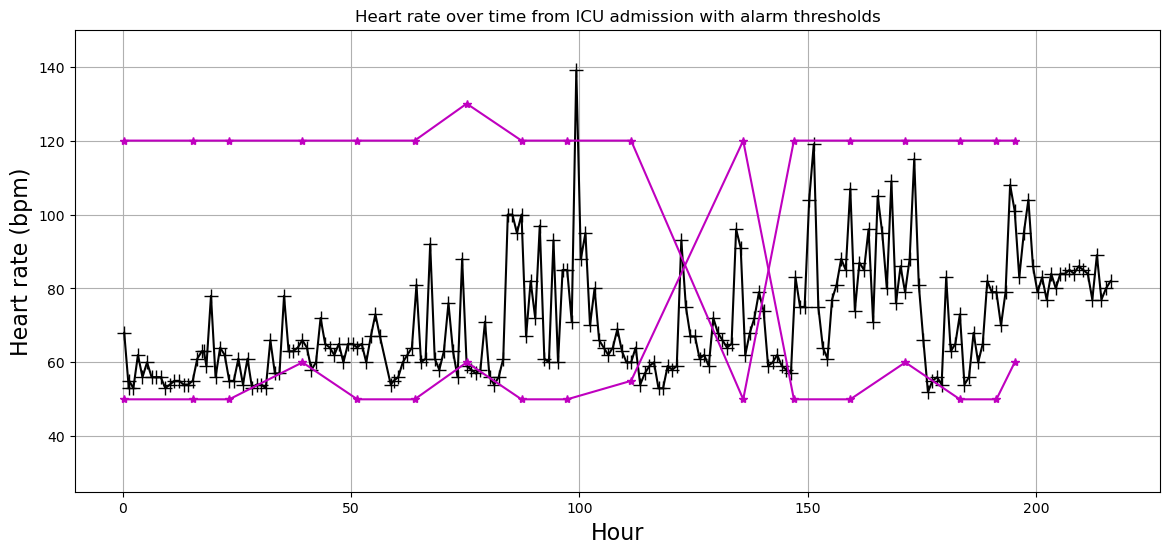

In [44]:
# Let's plot Heart rate over time from admission, with low alarm thresholds
# TO COMPLETE

plt.figure(figsize=(14, 6))

# Heart rate
plt.plot(
    df_ce1.index[df_ce1.label=='Heart Rate'],
    df_ce1.valuenum[df_ce1.label=='Heart Rate'],
    'k-+', markersize=10
)

# High alarm threshold
plt.plot(
    df_ce1.index[df_ce1.label=='Heart rate Alarm - High'], # they have a problem with upper and lower case normalization
    df_ce1.valuenum[df_ce1.label=='Heart rate Alarm - High'],
    'm-*'
)

# Low alarm threshold
plt.plot(
    df_ce1.index[df_ce1.label=='Heart Rate Alarm - Low'],
    df_ce1.valuenum[df_ce1.label=='Heart Rate Alarm - Low'],
    'm-*'
)

plt.xlabel('Hour', fontsize=16)
plt.ylabel('Heart rate (bpm)', fontsize=16)
plt.title('Heart rate over time from ICU admission with alarm thresholds')

plt.ylim(25, 150)
plt.grid(True)

plt.show()

We see that the alarm threshold is adjusted at the beginning to a more restrictive one.
And also we observe an artifact at eh end of the stay, where the alarm threshold is crossed -> probably labels were swapped.

### Plot 4: What is patient's level of consciousness?

Respiratory rate


Glasgow Coma Scale (GCS) is a measure of consciousness. It is commonly used for monitoring patients in the intensive care unit. It consists of three components: Eye response, Verbal response and Motor response.

In [45]:
# Display the first few rows of the GCS eye response data
df_ce1[df_ce1.label=='GCS - Eye Opening'].head()

,stay_id,value,valuenum,valueuom,label
hours,,,,,
0.333333,30757476,NaN,1.0,NaN,GCS - Eye Opening
3.466667,30757476,NaN,1.0,NaN,GCS - Eye Opening
8.200000,30757476,NaN,1.0,NaN,GCS - Eye Opening
16.333333,30757476,To Speech,3.0,NaN,GCS - Eye Opening
19.333333,30757476,To Speech,3.0,NaN,GCS - Eye Opening


In [46]:
df_ce1[df_ce1.label=='GCS - Motor Response'].head()

,stay_id,value,valuenum,valueuom,label
hours,,,,,
3.466667,30757476,No response,1.0,NaN,GCS - Motor Response
8.200000,30757476,Localizes Pain,5.0,NaN,GCS - Motor Response
16.333333,30757476,Obeys Commands,6.0,NaN,GCS - Motor Response
19.333333,30757476,Obeys Commands,6.0,NaN,GCS - Motor Response
23.333333,30757476,Obeys Commands,6.0,NaN,GCS - Motor Response


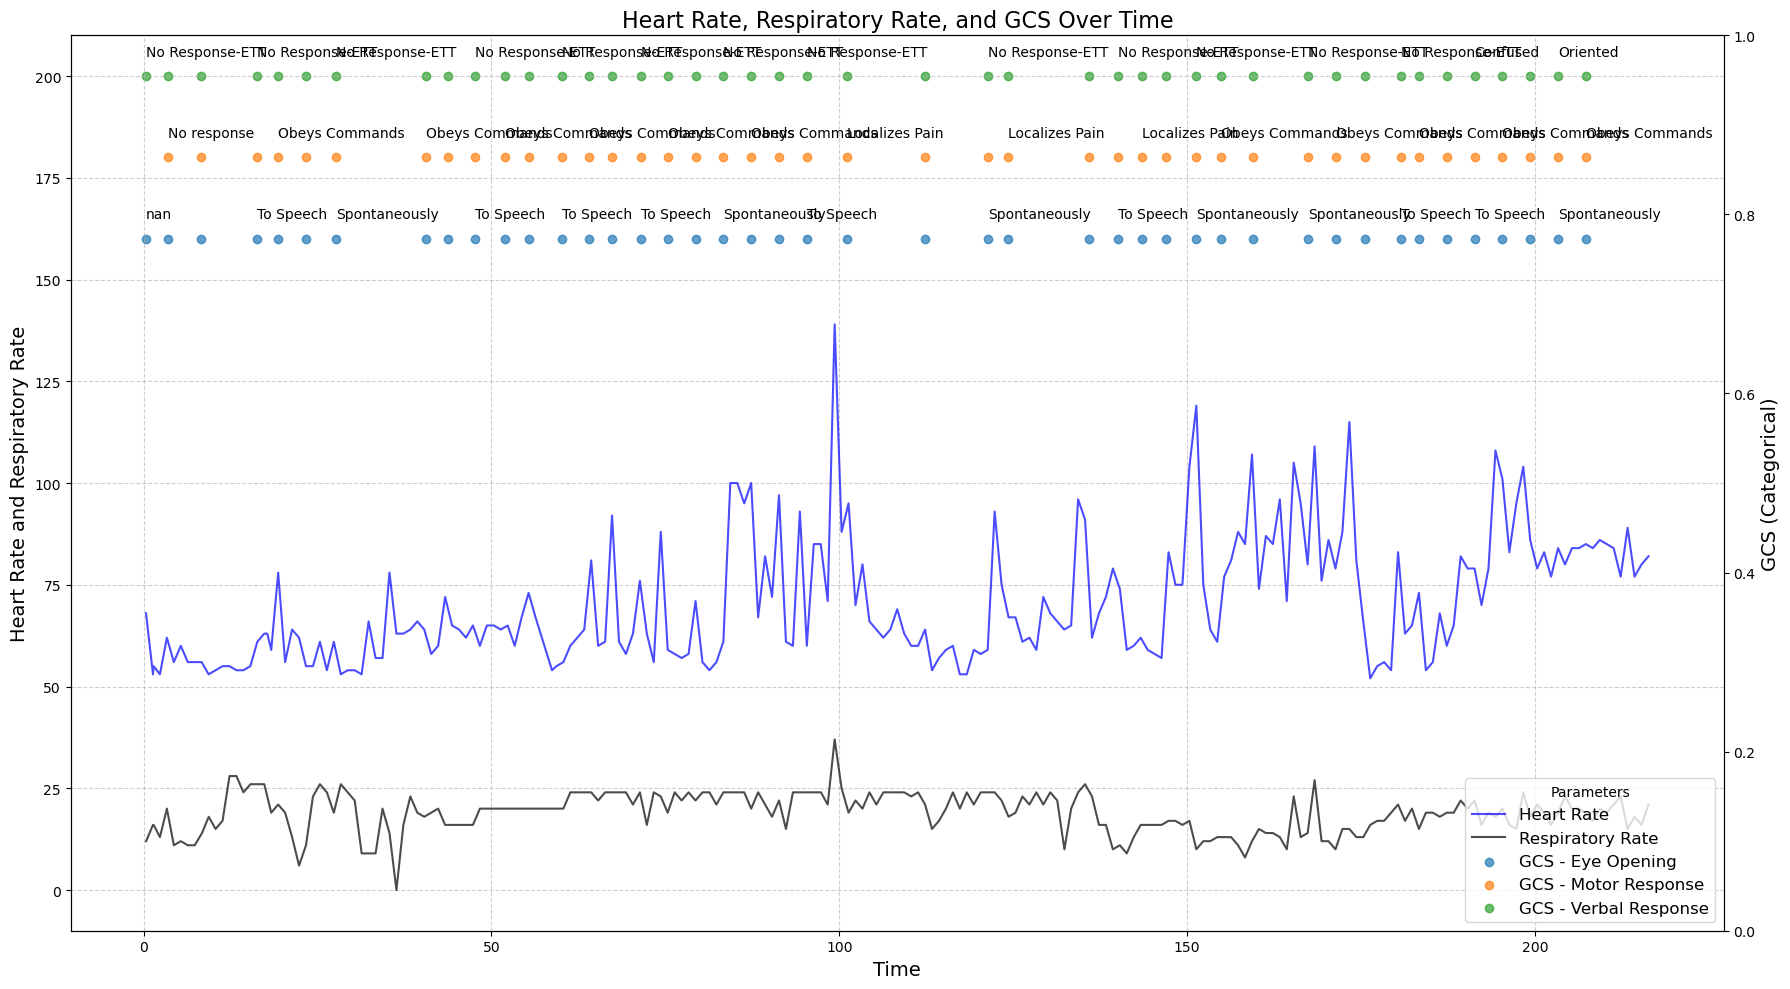

In [47]:
# Create a combined plot for GCS, Heart Rate, and Respiratory Rate
plt.figure(figsize=(18, 10))

# Plot Heart Rate and Respiratory Rate on primary y-axis
hr_subset = df_ce1[df_ce1.label == 'Heart Rate']
rr_subset = df_ce1[df_ce1.label == 'Respiratory Rate']

plt.plot(hr_subset.index, hr_subset.valuenum, label='Heart Rate', color='blue', alpha=0.7)
plt.plot(rr_subset.index, rr_subset.valuenum, label='Respiratory Rate', color='black', alpha=0.7)


# Plot GCS data as scatter points
gcs_components = ['GCS - Eye Opening', 'GCS - Motor Response', 'GCS - Verbal Response']
gcs_positions = [160, 180, 200]
c=0
for component in gcs_components:
    gcs_subset = df_ce1[df_ce1.label == component]
    plt.scatter(gcs_subset.index, [gcs_positions[c]] * len(gcs_subset), label=component, alpha=0.7)

    # Annotate GCS values dynamically 
    for i in range(0, len(gcs_subset), 3):  # Annotate every 5th point, for the sake of good visualization (otherwise the text is overlaping).
        plt.annotate(
            gcs_subset.value.iloc[i],(gcs_subset.index[i], gcs_positions[c]+5),  # Annotate near the GCS point
            fontsize=10,
            color='black'
        )
    c=c+1

# Add titles and labels
plt.title('Heart Rate, Respiratory Rate, and GCS Over Time', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Heart Rate and Respiratory Rate', fontsize=14)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Parameters', fontsize=12, loc='lower right')

# Secondary y-axis for GCS
plt.twinx()
plt.ylabel('GCS (Categorical)', fontsize=14)

# Tight layout and show plot
plt.tight_layout()
plt.show()


The patient's consciousness is changing over time, and we can plot this information together with the heart rate and espiratory rate.

## What about the patient's other vital signs?

We can visualise on a single plot several vital signs for the patient.


### Plot 5: How were the patient's other vital signs?

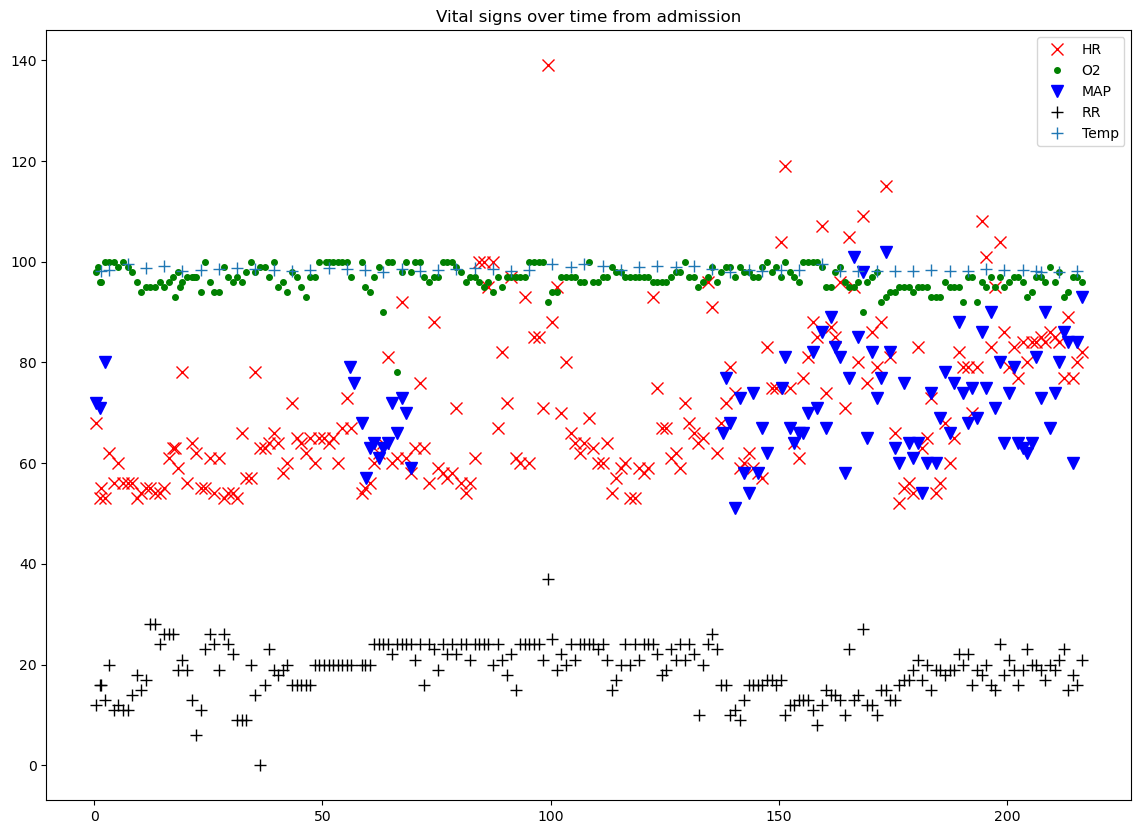

In [48]:
plt.figure(figsize=(14, 10))

plt.plot(df_ce1.index[df_ce1.label=='Heart Rate'], 
         df_ce1.valuenum[df_ce1.label=='Heart Rate'],
         'rx', markersize=8, label='HR')

plt.plot(df_ce1.index[df_ce1.label=='O2 saturation pulseoxymetry'], 
         df_ce1.valuenum[df_ce1.label=='O2 saturation pulseoxymetry'], 
         'g.', markersize=8, label='O2')

plt.plot(df_ce1.index[df_ce1.label=='Non Invasive Blood Pressure mean'], 
         df_ce1.valuenum[df_ce1.label=='Non Invasive Blood Pressure mean'], 
         'bv', markersize=8, label='MAP')

plt.plot(df_ce1.index[df_ce1.label=='Respiratory Rate'], 
         df_ce1.valuenum[df_ce1.label=='Respiratory Rate'], 
         'k+', markersize=8, label='RR')

plt.plot(df_ce1.index[df_ce1.label=='Temperature Fahrenheit'], 
         df_ce1.valuenum[df_ce1.label=='Temperature Fahrenheit'], 
         '+', markersize=8, label='Temp')

plt.title('Vital signs over time from admission')

plt.legend()

**Observation:** TO COMPLETE
Are the vital signs irregularly sampled?

Yes, this is normal as depending on the vital sign it will be sampled with a machine or by a nurse.
Example:
- O2 saturation pulseoxymetry is reagularly sample, probably by a machine.
- Non invasive blood preassure usually is done by a nurse in specific timestamps

**Exercise To complete:**

Analyse the timestep of the data in the previous plot.


In [53]:
df_ce1 = df_ce1.sort_index()

In [55]:
def compute_timestep(label):
    x = df_ce1[df_ce1.label == label].sort_index().index
    return x.to_series().diff()

for v in ['Heart Rate',
          'Respiratory Rate',
          'O2 saturation pulseoxymetry',
          'Non Invasive Blood Pressure mean',
          'Temperature Fahrenheit']:
    
    dt = compute_timestep(v)
    print("\n", v)
    print(dt.describe())


 Heart Rate
count    217.000000
mean       0.995392
std        0.124099
min        0.100000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.366667
Name: hours, dtype: float64

 Respiratory Rate
count    216.000000
mean       0.999923
std        0.115207
min        0.100000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.366667
Name: hours, dtype: float64

 O2 saturation pulseoxymetry
count    220.000000
mean       0.981667
std        0.152011
min        0.100000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.366667
Name: hours, dtype: float64

 Non Invasive Blood Pressure mean
count    94.000000
mean      2.297163
std       8.778053
min       0.566667
25%       1.000000
50%       1.000000
75%       1.000000
max      68.433333
Name: hours, dtype: float64

 Temperature Fahrenheit
count    55.000000
mean      3.889091
std       0.573060
min       1.000000
25%       4.000000
50%       4.000000
75%       4.000000
m

- Heart rate: sampled every hour more or less
- Respiratory rate: every hour too
- O2 saturation: every hour
- non invasive blood preassure: every 2 hours, very variable
- temperature: every 4 hours, very variable

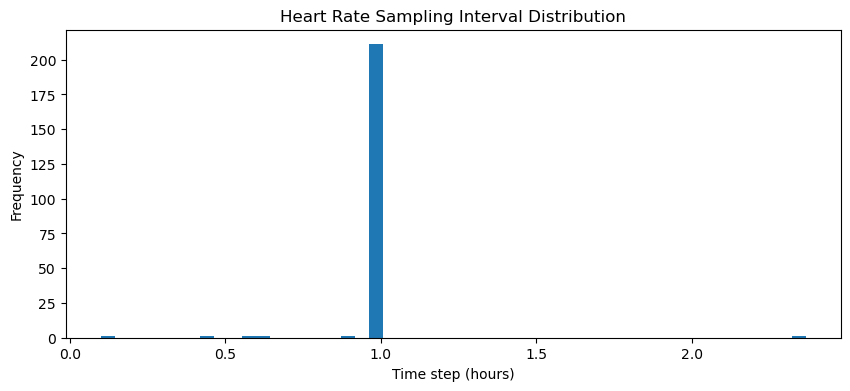

In [56]:
hr = df_ce1[df_ce1.label == 'Heart Rate'].copy()
dt = hr.index.to_series().diff()

plt.figure(figsize=(10,4))
plt.hist(dt.dropna(), bins=50)
plt.title("Heart Rate Sampling Interval Distribution")
plt.xlabel("Time step (hours)")
plt.ylabel("Frequency")
plt.show()

### Plot 6: What about the laboratory measurements?

Let us plot laboratory measurements (using tables LABEVENTS and D_LABITEMS) over time: Hematocrit and Hemoglobin

We read the LABEVENTS data. This data corresponds to measurements made in a laboratory - usually on a sample of patient blood. 

In [57]:
df_labevents=pd.read_csv(path+'hosp/labevents.csv.gz')
print(df_labevents.shape)
df_labevents.head()

(107727, 16)


,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,172061,10014354,29600294.0,1808066,51277,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,15.4,15.40,%,10.5,15.5,NaN,ROUTINE,NaN
1,172062,10014354,29600294.0,1808066,51279,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,3.35,3.35,m/uL,4.6,6.1,abnormal,ROUTINE,NaN
2,172068,10014354,29600294.0,1808066,52172,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,49.7,49.70,fL,35.1,46.3,abnormal,ROUTINE,NaN
3,172063,10014354,29600294.0,1808066,51301,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,20.3,20.30,K/uL,4.0,10.0,abnormal,ROUTINE,NaN
4,172050,10014354,29600294.0,1808066,51249,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,31.1,31.10,g/dL,32.0,37.0,abnormal,ROUTINE,NaN


In [58]:
df_labevents.drop(df_labevents.columns.difference(['subject_id', 'hadm_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom']), axis=1, inplace=True)
print(df_labevents.shape)
df_labevents.head()

(107727, 7)


,subject_id,hadm_id,itemid,charttime,value,valuenum,valueuom
0,10014354,29600294.0,51277,2148-08-16 00:00:00,15.4,15.40,%
1,10014354,29600294.0,51279,2148-08-16 00:00:00,3.35,3.35,m/uL
2,10014354,29600294.0,52172,2148-08-16 00:00:00,49.7,49.70,fL
3,10014354,29600294.0,51301,2148-08-16 00:00:00,20.3,20.30,K/uL
4,10014354,29600294.0,51249,2148-08-16 00:00:00,31.1,31.10,g/dL


In [59]:
df_labitems=pd.read_csv(path+'hosp/d_labitems.csv.gz')
print(df_labitems.shape)
df_labitems.head()

(1622, 4)


,itemid,label,fluid,category
0,50808,Free Calcium,Blood,Blood Gas
1,50826,Tidal Volume,Blood,Blood Gas
2,50813,Lactate,Blood,Blood Gas
3,52029,% Ionized Calcium,Blood,Blood Gas
4,50801,Alveolar-arterial Gradient,Blood,Blood Gas


In [60]:
df_labitems.drop(df_labitems.columns.difference(['itemid', 'label']), axis=1, inplace=True)
print(df_labitems.shape)
df_labitems.head()

(1622, 2)


,itemid,label
0,50808,Free Calcium
1,50826,Tidal Volume
2,50813,Lactate
3,52029,% Ionized Calcium
4,50801,Alveolar-arterial Gradient


In [61]:
df_labitems.drop(df_labitems.columns.difference(['itemid', 'label']), axis=1, inplace=True)
print(df_labitems.shape)
df_labitems.head()

(1622, 2)


,itemid,label
0,50808,Free Calcium
1,50826,Tidal Volume
2,50813,Lactate
3,52029,% Ionized Calcium
4,50801,Alveolar-arterial Gradient


In [62]:
le=pd.merge(df_labevents,df_labitems,how='left',on=['itemid']) # name le from lab events
print(le.shape)
# preview the labevents data
le.head()

(107727, 8)


,subject_id,hadm_id,itemid,charttime,value,valuenum,valueuom,label
0,10014354,29600294.0,51277,2148-08-16 00:00:00,15.4,15.40,%,RDW
1,10014354,29600294.0,51279,2148-08-16 00:00:00,3.35,3.35,m/uL,Red Blood Cells
2,10014354,29600294.0,52172,2148-08-16 00:00:00,49.7,49.70,fL,RDW-SD
3,10014354,29600294.0,51301,2148-08-16 00:00:00,20.3,20.30,K/uL,White Blood Cells
4,10014354,29600294.0,51249,2148-08-16 00:00:00,31.1,31.10,g/dL,MCHC


Let us select subject with id=10014354

In [63]:
le = le[le['subject_id']==10014354] 
print(le.shape)

(9711, 8)


Let us extract the Hemoglobin and Hematocrit time serie.

In [64]:
# preview the ioevents data
le[le.label=='Hemoglobin']

,subject_id,hadm_id,itemid,charttime,value,valuenum,valueuom,label
6,10014354,29600294.0,51222,2148-08-16 00:00:00,9.2,9.2,g/dL,Hemoglobin
105,10014354,26486158.0,51222,2148-08-24 00:00:00,8.0,8.0,g/dL,Hemoglobin
230,10014354,24980601.0,51222,2150-02-08 00:00:00,9.7,9.7,g/dL,Hemoglobin
537,10014354,26486158.0,51222,2148-09-08 08:00:00,8.6,8.6,g/dL,Hemoglobin
603,10014354,NaN,51222,2147-09-16 10:00:00,10.0,10.0,g/dL,Hemoglobin
...,...,...,...,...,...,...,...,...
103688,10014354,26486158.0,51222,2148-09-07 05:55:00,8.2,8.2,g/dL,Hemoglobin
104318,10014354,23132022.0,51222,2148-06-27 05:56:00,8.6,8.6,g/dL,Hemoglobin
104425,10014354,NaN,51222,2150-07-04 10:56:00,9.3,9.3,g/dL,Hemoglobin
107074,10014354,27562275.0,51222,2148-07-18 05:59:00,8.7,8.7,g/dL,Hemoglobin


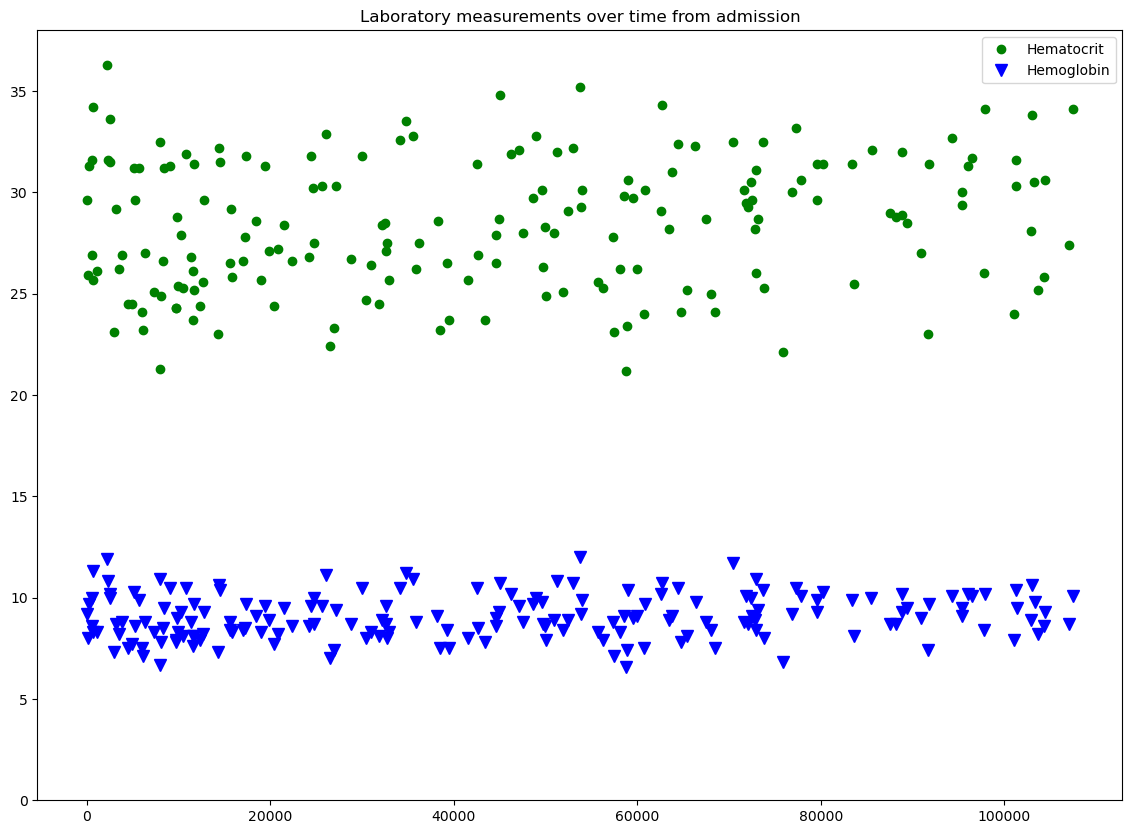

In [65]:
plt.figure(figsize=(14, 10))

plt.plot(le.index[le.label=='Hematocrit'], 
         le.valuenum[le.label=='Hematocrit'], 
         'go', markersize=6, label='Hematocrit')

plt.plot(le.index[le.label=='Hemoglobin'], 
         le.valuenum[le.label=='Hemoglobin'], 
         'bv', markersize=8, label='Hemoglobin')

plt.title('Laboratory measurements over time from admission')
plt.ylim(0,38)
plt.legend()

**Exercise To complete:**

Analyse the timestep of the data in the previous plot.

In [70]:
le_sorted = le.sort_index()

In [71]:
hct = le_sorted[le_sorted.label == 'Hematocrit']
dt_hct = hct.index.to_series().diff()
print(dt_hct.describe())

count     187.000000
mean      574.775401
std       595.646647
min         6.000000
25%       157.000000
50%       396.000000
75%       744.500000
max      3246.000000
dtype: float64


In [72]:
hgb = le_sorted[le_sorted.label == 'Hemoglobin']
dt_hgb = hgb.index.to_series().diff()
print(dt_hgb.describe())

count     186.000000
mean      577.849462
std       600.934155
min         7.000000
25%       155.500000
50%       394.500000
75%       748.250000
max      3243.000000
dtype: float64


**Conclusion**: The study of the time series can allow doctors control the clinical evolution of a patient or the effect of giving the pacient certain medications.